# Dataset Quality & Performance Analysis
## Chatbot RAG — FSSM / UCA Marrakech

Ce notebook analyse la **qualité**, la **cohérence** et les **statistiques** du dataset JSON utilisé pour le système RAG.

---
**Objectifs :**
- Charger et valider tous les fichiers JSON
- Vérifier la structure et la complétude de chaque objet
- Analyser les distributions (tags, catégories, longueurs)
- Détecter les doublons et anomalies
- Générer un rapport de qualité complet

## 1. Imports & Configuration

In [1]:
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Chemin racine du dataset ───────────────────────────────────
DATASET_ROOT = Path('../dataset')          # adapter si besoin
REQUIRED_FIELDS = ['id', 'questions', 'answers', 'context', 'tags', 'source', 'category']

print('✅ Imports OK')
print(f'📁 Dataset root : {DATASET_ROOT.resolve()}')

✅ Imports OK
📁 Dataset root : C:\Users\HP\Desktop\S2\7 - Deep Learning\3 - Projet\Projet_DL_N\Projet_DL\dataset


## 2. Chargement de tous les fichiers JSON

In [3]:
def load_all_json(root: Path) -> dict:
    """Charge tous les .json du dataset et retourne un dict structuré."""
    data = {}
    errors = []
    for json_file in sorted(root.rglob('*.json')):
        if json_file.name == "final_dataset.json":
            continue
        rel = json_file.relative_to(root)
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                content = json.load(f)
            data[str(rel)] = content
            print(f'  ✅  {rel}  →  {len(content)} objets')
        except Exception as e:
            errors.append((str(rel), str(e)))
            print(f'  ❌  {rel}  →  ERREUR : {e}')
    print(f'\n📊 Total fichiers chargés : {len(data)} / {len(data)+len(errors)}')
    return data, errors

all_data, load_errors = load_all_json(DATASET_ROOT)

  ✅  administratif\documents.json  →  20 objets
  ✅  administratif\inscription.json  →  20 objets
  ✅  administratif\scolarite.json  →  20 objets
  ✅  formations\doctorat.json  →  20 objets
  ✅  formations\licences.json  →  20 objets
  ✅  formations\masters.json  →  20 objets
  ✅  pedagogie\absences.json  →  20 objets
  ✅  pedagogie\examens.json  →  20 objets
  ✅  pedagogie\rattrapage.json  →  20 objets
  ✅  pedagogie\redoublement.json  →  20 objets
  ✅  pedagogie\validation_modules.json  →  20 objets
  ✅  universite\departements.json  →  20 objets
  ✅  universite\facultes.json  →  20 objets
  ✅  universite\infrastructure.json  →  20 objets
  ✅  universite\presidence.json  →  20 objets

📊 Total fichiers chargés : 15 / 15


In [4]:
# Aplatir tous les objets dans une liste globale
all_objects = []
for file_path, objects in all_data.items():
    for obj in objects:
        obj['_file'] = file_path          # méta : fichier d'origine
        all_objects.append(obj)

df = pd.DataFrame(all_objects)
print(f'\n🗂️  Total objets chargés : {len(df)}')
print(f'🗂️  Colonnes disponibles  : {list(df.columns)}')
df.head(3)


🗂️  Total objets chargés : 300
🗂️  Colonnes disponibles  : ['id', 'questions', 'answers', 'context', 'tags', 'source', 'category', '_file']


,id,questions,answers,context,tags,source,category,_file
0,adm_doc_001,[Quels documents sont nécessaires pour l'inscr...,"[Copie du bac, CIN et photos d'identité. Un do...",L'étudiant doit fournir une copie du baccalaur...,"[documents, inscription, administratif]",FSSM UCA - site officiel,administratif,administratif\documents.json
1,adm_doc_002,[Comment obtenir une attestation d'inscription...,[L'attestation d'inscription est délivrée par ...,L'attestation d'inscription est un document of...,"[attestation, inscription, scolarité, document...",FSSM UCA - service scolarité,administratif,administratif\documents.json
2,adm_doc_003,[Comment obtenir un relevé de notes à la FSSM ...,[Le relevé de notes est disponible auprès du s...,Le relevé de notes officiel de la FSSM est fou...,"[relevé de notes, résultats, scolarité]",FSSM UCA - portail notes,administratif,administratif\documents.json


## 3. Validation de la structure

In [5]:
def validate_object(obj: dict, required: list) -> list:
    """Retourne la liste des erreurs de validation pour un objet."""
    errors = []
    # Champs manquants
    for field in required:
        if field not in obj or obj[field] is None:
            errors.append(f'Champ manquant : {field}')
    # Champs vides
    if 'questions' in obj and isinstance(obj['questions'], list):
        if len(obj['questions']) == 0:
            errors.append('questions est vide')
        if len(obj['questions']) < 2:
            errors.append(f'questions : seulement {len(obj["questions"])} variante(s) — recommandé ≥ 2')
    if 'answers' in obj and isinstance(obj['answers'], list):
        if len(obj['answers']) == 0:
            errors.append('answers est vide')
    if 'context' in obj:
        if not isinstance(obj['context'], str) or len(obj['context'].strip()) < 20:
            errors.append('context trop court ou invalide')
    if 'tags' in obj and isinstance(obj['tags'], list):
        if len(obj['tags']) == 0:
            errors.append('tags vide')
    if 'id' in obj:
        if not re.match(r'^[a-z]{2,8}_[a-z]{2,8}_\d{3}$', str(obj['id'])):
            errors.append(f'Format id invalide : {obj["id"]}')
    return errors

# Validation de tous les objets
validation_report = []
for obj in all_objects:
    errs = validate_object(obj, REQUIRED_FIELDS)
    if errs:
        validation_report.append({
            'id': obj.get('id', 'N/A'),
            'fichier': obj.get('_file', 'N/A'),
            'erreurs': ' | '.join(errs),
            'nb_erreurs': len(errs)
        })

df_val = pd.DataFrame(validation_report)
valid_count   = len(all_objects) - len(df_val)
invalid_count = len(df_val)

print(f'\n✅ Objets valides   : {valid_count}')
print(f'❌ Objets invalides : {invalid_count}')
print(f'📈 Taux de validité : {valid_count/len(all_objects)*100:.1f}%')
if not df_val.empty:
    display(df_val.sort_values('nb_erreurs', ascending=False).head(10))


✅ Objets valides   : 280
❌ Objets invalides : 20
📈 Taux de validité : 93.3%


,id,fichier,erreurs,nb_erreurs
0,exam_001,pedagogie\examens.json,Format id invalide : exam_001,1
1,exam_002,pedagogie\examens.json,Format id invalide : exam_002,1
2,exam_003,pedagogie\examens.json,Format id invalide : exam_003,1
3,exam_004,pedagogie\examens.json,Format id invalide : exam_004,1
4,exam_005,pedagogie\examens.json,Format id invalide : exam_005,1
5,exam_006,pedagogie\examens.json,Format id invalide : exam_006,1
6,exam_007,pedagogie\examens.json,Format id invalide : exam_007,1
7,exam_008,pedagogie\examens.json,Format id invalide : exam_008,1
8,exam_009,pedagogie\examens.json,Format id invalide : exam_009,1
9,exam_010,pedagogie\examens.json,Format id invalide : exam_010,1


## 4. Statistiques globales

In [6]:
# ── Statistiques par fichier ───────────────────────────────────
file_stats = []
for file_path, objects in all_data.items():
    file_stats.append({
        'Fichier': file_path,
        'Catégorie': objects[0].get('category', 'N/A') if objects else 'N/A',
        'Nb objets': len(objects),
        'Moy. questions': round(np.mean([len(o.get('questions',[])) for o in objects]), 2),
        'Moy. réponses':  round(np.mean([len(o.get('answers',[])) for o in objects]), 2),
        'Moy. tags':      round(np.mean([len(o.get('tags',[])) for o in objects]), 2),
        'Moy. len context': round(np.mean([len(o.get('context','')) for o in objects]), 1),
    })

df_stats = pd.DataFrame(file_stats)
print('📋 Statistiques par fichier :')
display(df_stats.to_string(index=False))
print(f'\n📦 TOTAL OBJETS : {df_stats["Nb objets"].sum()}')

📋 Statistiques par fichier :


'                          Fichier     Catégorie  Nb objets  Moy. questions  Moy. réponses  Moy. tags  Moy. len context\n     administratif\\documents.json administratif         20             4.0            1.0       3.80             168.6\n   administratif\\inscription.json administratif         20             4.0            1.0       4.50             174.4\n     administratif\\scolarite.json administratif         20             4.0            1.0       4.75             165.6\n         formations\\doctorat.json     formation         20             4.0            1.0       5.00             167.2\n         formations\\licences.json     formation         20             4.0            1.0       5.20             169.7\n          formations\\masters.json     formation         20             4.0            1.0       5.25             163.4\n          pedagogie\\absences.json     pédagogie         20             4.0            1.0       5.15             163.4\n           pedagogie\\examens.js


📦 TOTAL OBJETS : 300


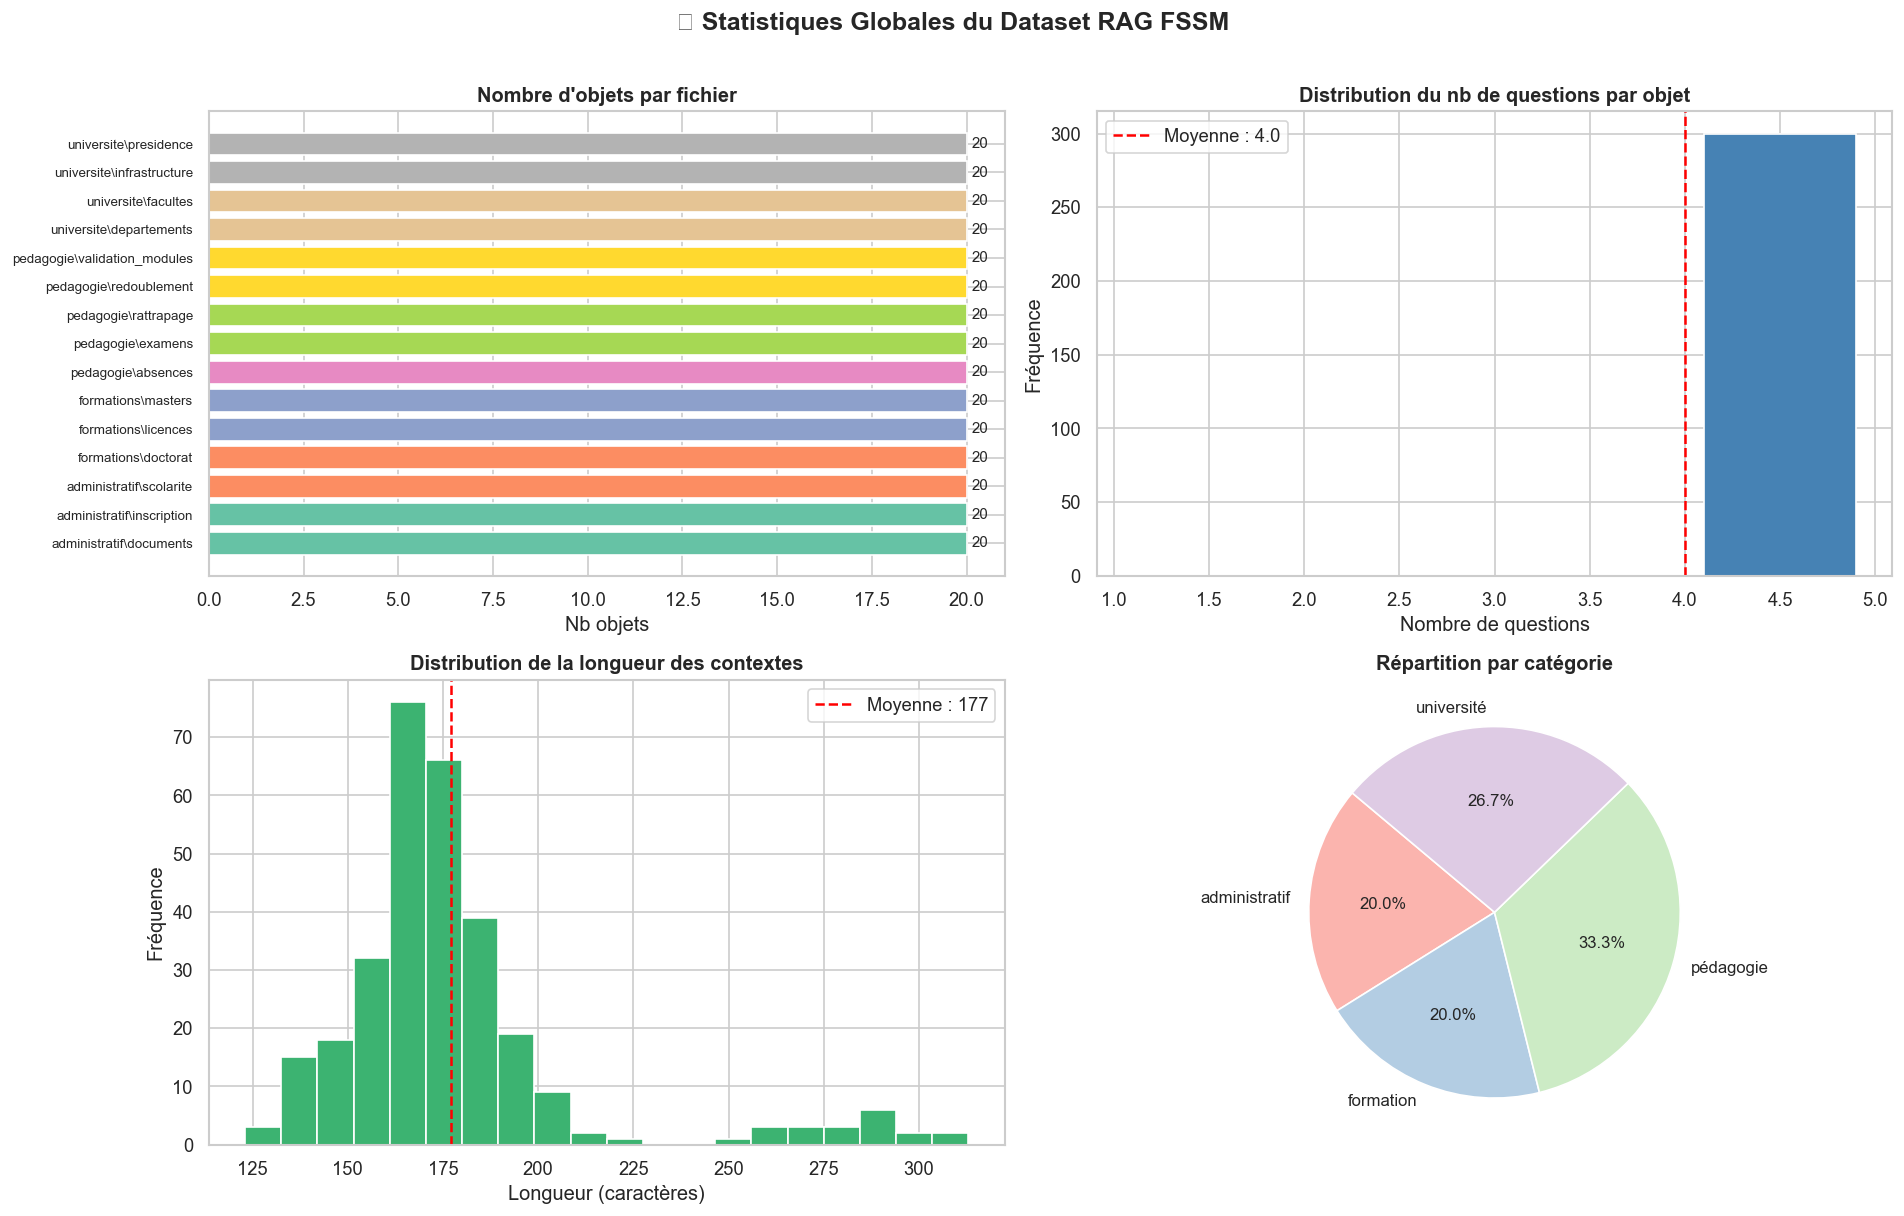

📁 Graphique sauvegardé : dataset_statistics.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📊 Statistiques Globales du Dataset RAG FSSM', fontsize=15, fontweight='bold', y=1.01)

# 1) Objets par fichier
ax = axes[0, 0]
colors = plt.cm.Set2(np.linspace(0, 1, len(df_stats)))
bars = ax.barh(df_stats['Fichier'].apply(lambda x: x.replace('.json','')), df_stats['Nb objets'], color=colors)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Nombre d\'objets par fichier', fontweight='bold')
ax.set_xlabel('Nb objets')
ax.tick_params(axis='y', labelsize=8)

# 2) Distribution questions par objet
ax = axes[0, 1]
n_questions = [len(o.get('questions', [])) for o in all_objects]
ax.hist(n_questions, bins=range(1, max(n_questions)+2), color='steelblue', edgecolor='white', rwidth=0.8)
ax.set_title('Distribution du nb de questions par objet', fontweight='bold')
ax.set_xlabel('Nombre de questions')
ax.set_ylabel('Fréquence')
ax.axvline(np.mean(n_questions), color='red', linestyle='--', label=f'Moyenne : {np.mean(n_questions):.1f}')
ax.legend()

# 3) Longueur des contextes
ax = axes[1, 0]
ctx_lengths = [len(o.get('context', '')) for o in all_objects]
ax.hist(ctx_lengths, bins=20, color='mediumseagreen', edgecolor='white')
ax.set_title('Distribution de la longueur des contextes', fontweight='bold')
ax.set_xlabel('Longueur (caractères)')
ax.set_ylabel('Fréquence')
ax.axvline(np.mean(ctx_lengths), color='red', linestyle='--', label=f'Moyenne : {np.mean(ctx_lengths):.0f}')
ax.legend()

# 4) Répartition par catégorie
ax = axes[1, 1]
cats = Counter(o.get('category', 'N/A') for o in all_objects)
ax.pie(cats.values(), labels=cats.keys(), autopct='%1.1f%%',
       colors=plt.cm.Pastel1.colors, startangle=140, textprops={'fontsize':10})
ax.set_title('Répartition par catégorie', fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_statistics.png', bbox_inches='tight')
plt.show()
print('📁 Graphique sauvegardé : dataset_statistics.png')

## 5. Analyse des tags

In [8]:
# Fréquence globale des tags
all_tags = []
for obj in all_objects:
    all_tags.extend([t.lower().strip() for t in obj.get('tags', [])])

tag_counter = Counter(all_tags)
top_tags = tag_counter.most_common(30)

print(f'🏷️  Tags uniques       : {len(tag_counter)}')
print(f'🏷️  Tags totaux        : {len(all_tags)}')
print(f'🏷️  Moy. tags/objet   : {len(all_tags)/len(all_objects):.2f}')
print(f'\n🔝 Top 10 tags :')
for tag, count in top_tags[:10]:
    print(f'   {tag:30s} → {count} fois')

🏷️  Tags uniques       : 663
🏷️  Tags totaux        : 1491
🏷️  Moy. tags/objet   : 4.97

🔝 Top 10 tags :
   master                         → 32 fois
   rattrapage                     → 23 fois
   scolarité                      → 22 fois
   examens                        → 21 fois
   semestre                       → 18 fois
   redoublement                   → 18 fois
   uca                            → 18 fois
   inscription                    → 16 fois
   doctorat                       → 16 fois
   campus                         → 16 fois


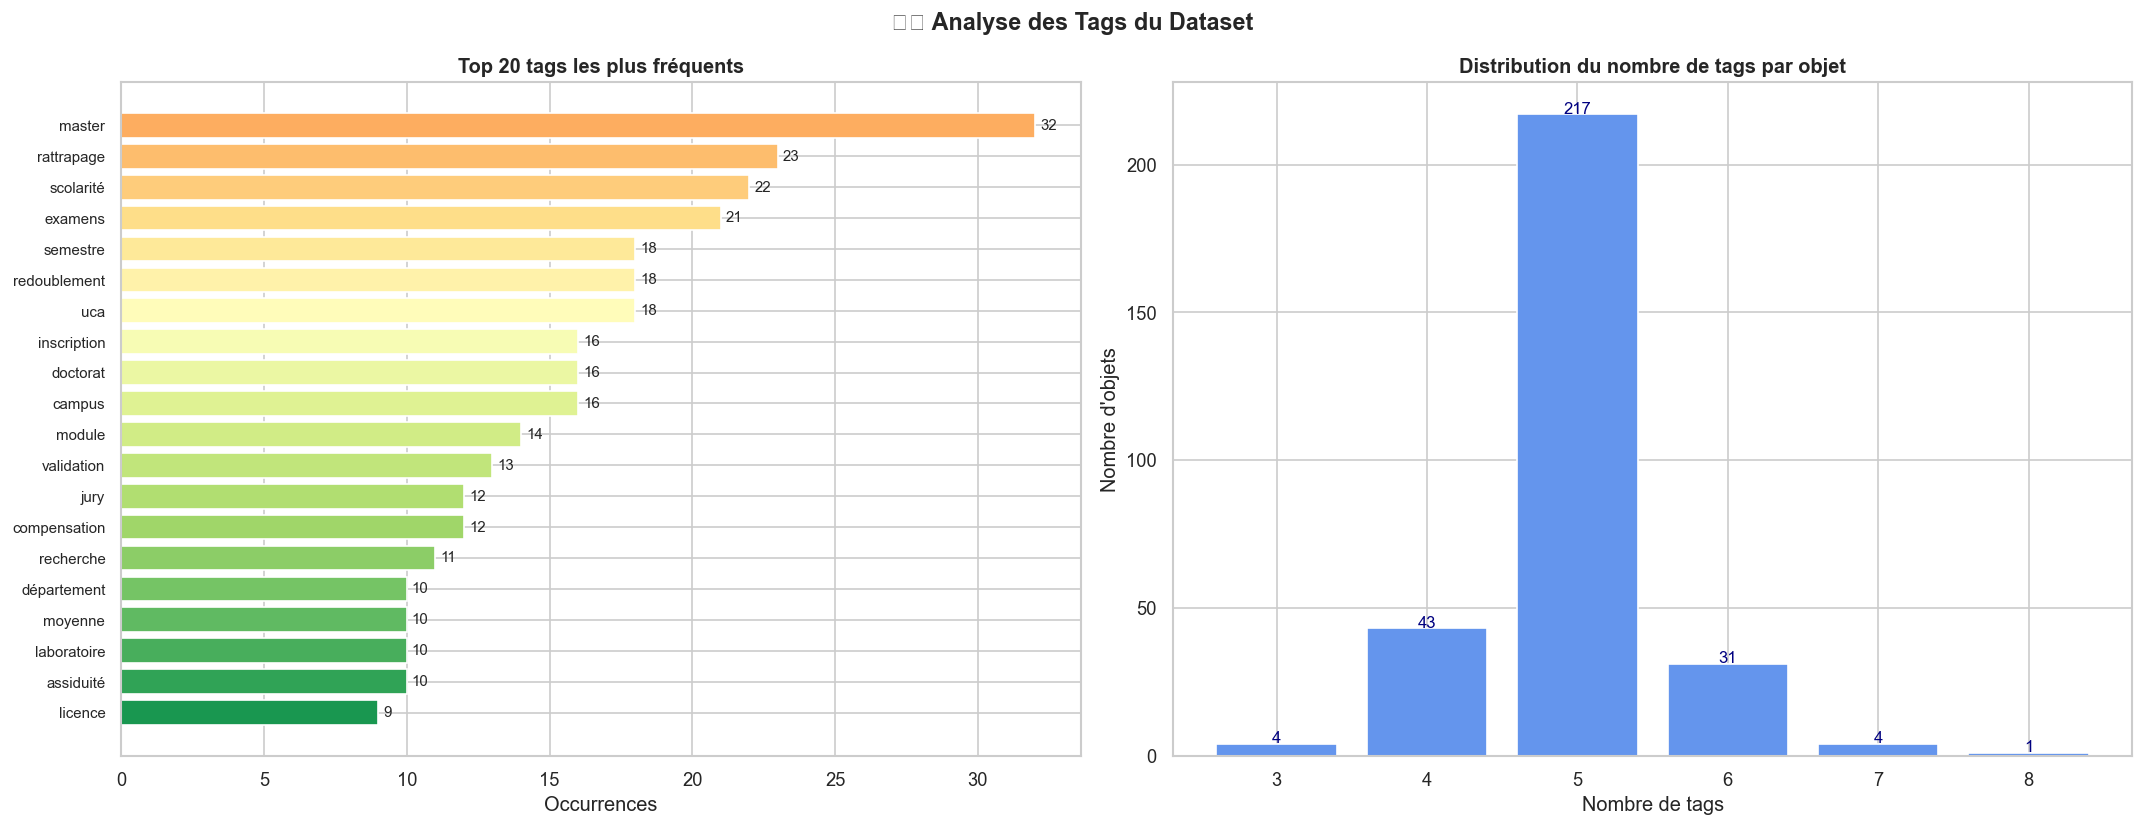

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🏷️ Analyse des Tags du Dataset', fontsize=14, fontweight='bold')

# Top 20 tags
ax = axes[0]
tags_names, tags_counts = zip(*top_tags[:20])
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(tags_names)))
bars = ax.barh(list(reversed(tags_names)), list(reversed(tags_counts)), color=list(reversed(colors)))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Top 20 tags les plus fréquents', fontweight='bold')
ax.set_xlabel('Occurrences')
ax.tick_params(axis='y', labelsize=9)

# Distribution du nombre de tags par objet
ax = axes[1]
nb_tags = [len(o.get('tags', [])) for o in all_objects]
cnt = Counter(nb_tags)
ax.bar(cnt.keys(), cnt.values(), color='cornflowerblue', edgecolor='white')
ax.set_title('Distribution du nombre de tags par objet', fontweight='bold')
ax.set_xlabel('Nombre de tags')
ax.set_ylabel('Nombre d\'objets')
for k, v in cnt.items():
    ax.text(k, v+0.3, str(v), ha='center', fontsize=10, color='navy')

plt.tight_layout()
plt.savefig('tags_analysis.png', bbox_inches='tight')
plt.show()

## 6. Détection des doublons

In [10]:
# ── Doublons d'ID ─────────────────────────────────────────────
ids = [o.get('id') for o in all_objects]
id_counter = Counter(ids)
dup_ids = {k: v for k, v in id_counter.items() if v > 1}

print('🔍 Détection des doublons\n')
print(f'  IDs dupliqués     : {len(dup_ids)}')
if dup_ids:
    for dup_id, count in dup_ids.items():
        print(f'    → "{dup_id}" apparaît {count} fois')
else:
    print('  ✅ Aucun ID dupliqué')

# ── Doublons de contexte ──────────────────────────────────────
ctx_list = [o.get('context','').strip().lower() for o in all_objects]
ctx_counter = Counter(ctx_list)
dup_ctx = {k[:60]+'...': v for k, v in ctx_counter.items() if v > 1}
print(f'\n  Contextes dupliqués : {len(dup_ctx)}')
if dup_ctx:
    for c, cnt in list(dup_ctx.items())[:5]:
        print(f'    → "{c}" — {cnt} fois')
else:
    print('  ✅ Aucun contexte dupliqué')

# ── Questions dupliquées entre objets ─────────────────────────
all_questions = []
for obj in all_objects:
    for q in obj.get('questions', []):
        all_questions.append(q.strip().lower())

q_counter = Counter(all_questions)
dup_q = {k: v for k, v in q_counter.items() if v > 1}
print(f'\n  Questions dupliquées  : {len(dup_q)}')
if dup_q:
    for q, cnt in list(dup_q.items())[:5]:
        print(f'    → "{q[:70]}" — {cnt} fois')
else:
    print('  ✅ Aucune question dupliquée')

🔍 Détection des doublons

  IDs dupliqués     : 0
  ✅ Aucun ID dupliqué

  Contextes dupliqués : 0
  ✅ Aucun contexte dupliqué

  Questions dupliquées  : 3
    → "adresse fssm marrakech ?" — 2 fois
    → "plateforme candidature master fssm ?" — 2 fois
    → "résultats examens fssm en ligne ?" — 2 fois


## 7. Analyse de la longueur des textes (NLP)

In [11]:
def word_count(text: str) -> int:
    return len(text.split())

records = []
for obj in all_objects:
    ctx      = obj.get('context', '')
    questions = obj.get('questions', [])
    answers   = obj.get('answers', [])
    records.append({
        'id'             : obj.get('id'),
        'category'       : obj.get('category'),
        'fichier'        : obj.get('_file'),
        'ctx_chars'      : len(ctx),
        'ctx_words'      : word_count(ctx),
        'nb_questions'   : len(questions),
        'avg_q_len'      : np.mean([len(q) for q in questions]) if questions else 0,
        'avg_q_words'    : np.mean([word_count(q) for q in questions]) if questions else 0,
        'nb_answers'     : len(answers),
        'avg_ans_len'    : np.mean([len(a) for a in answers]) if answers else 0,
        'avg_ans_words'  : np.mean([word_count(a) for a in answers]) if answers else 0,
        'nb_tags'        : len(obj.get('tags', [])),
    })

df_nlp = pd.DataFrame(records)

print('📏 Statistiques NLP globales :\n')
stats_cols = ['ctx_chars','ctx_words','nb_questions','avg_q_words','avg_ans_words','nb_tags']
desc = df_nlp[stats_cols].describe().round(2)
display(desc)

📏 Statistiques NLP globales :



,ctx_chars,ctx_words,nb_questions,avg_q_words,avg_ans_words,nb_tags
count,300.00,300.00,300.0,300.00,300.00,300.00
mean,177.22,26.69,4.0,6.49,35.57,4.97
std,32.24,5.41,0.0,0.94,7.35,0.62
min,123.00,19.00,4.0,4.50,11.60,3.00
25%,161.00,24.00,4.0,5.75,33.00,5.00
50%,171.00,25.50,4.0,6.50,37.00,5.00
75%,182.25,28.00,4.0,7.00,39.00,5.00
max,313.00,50.00,4.0,9.25,53.00,8.00


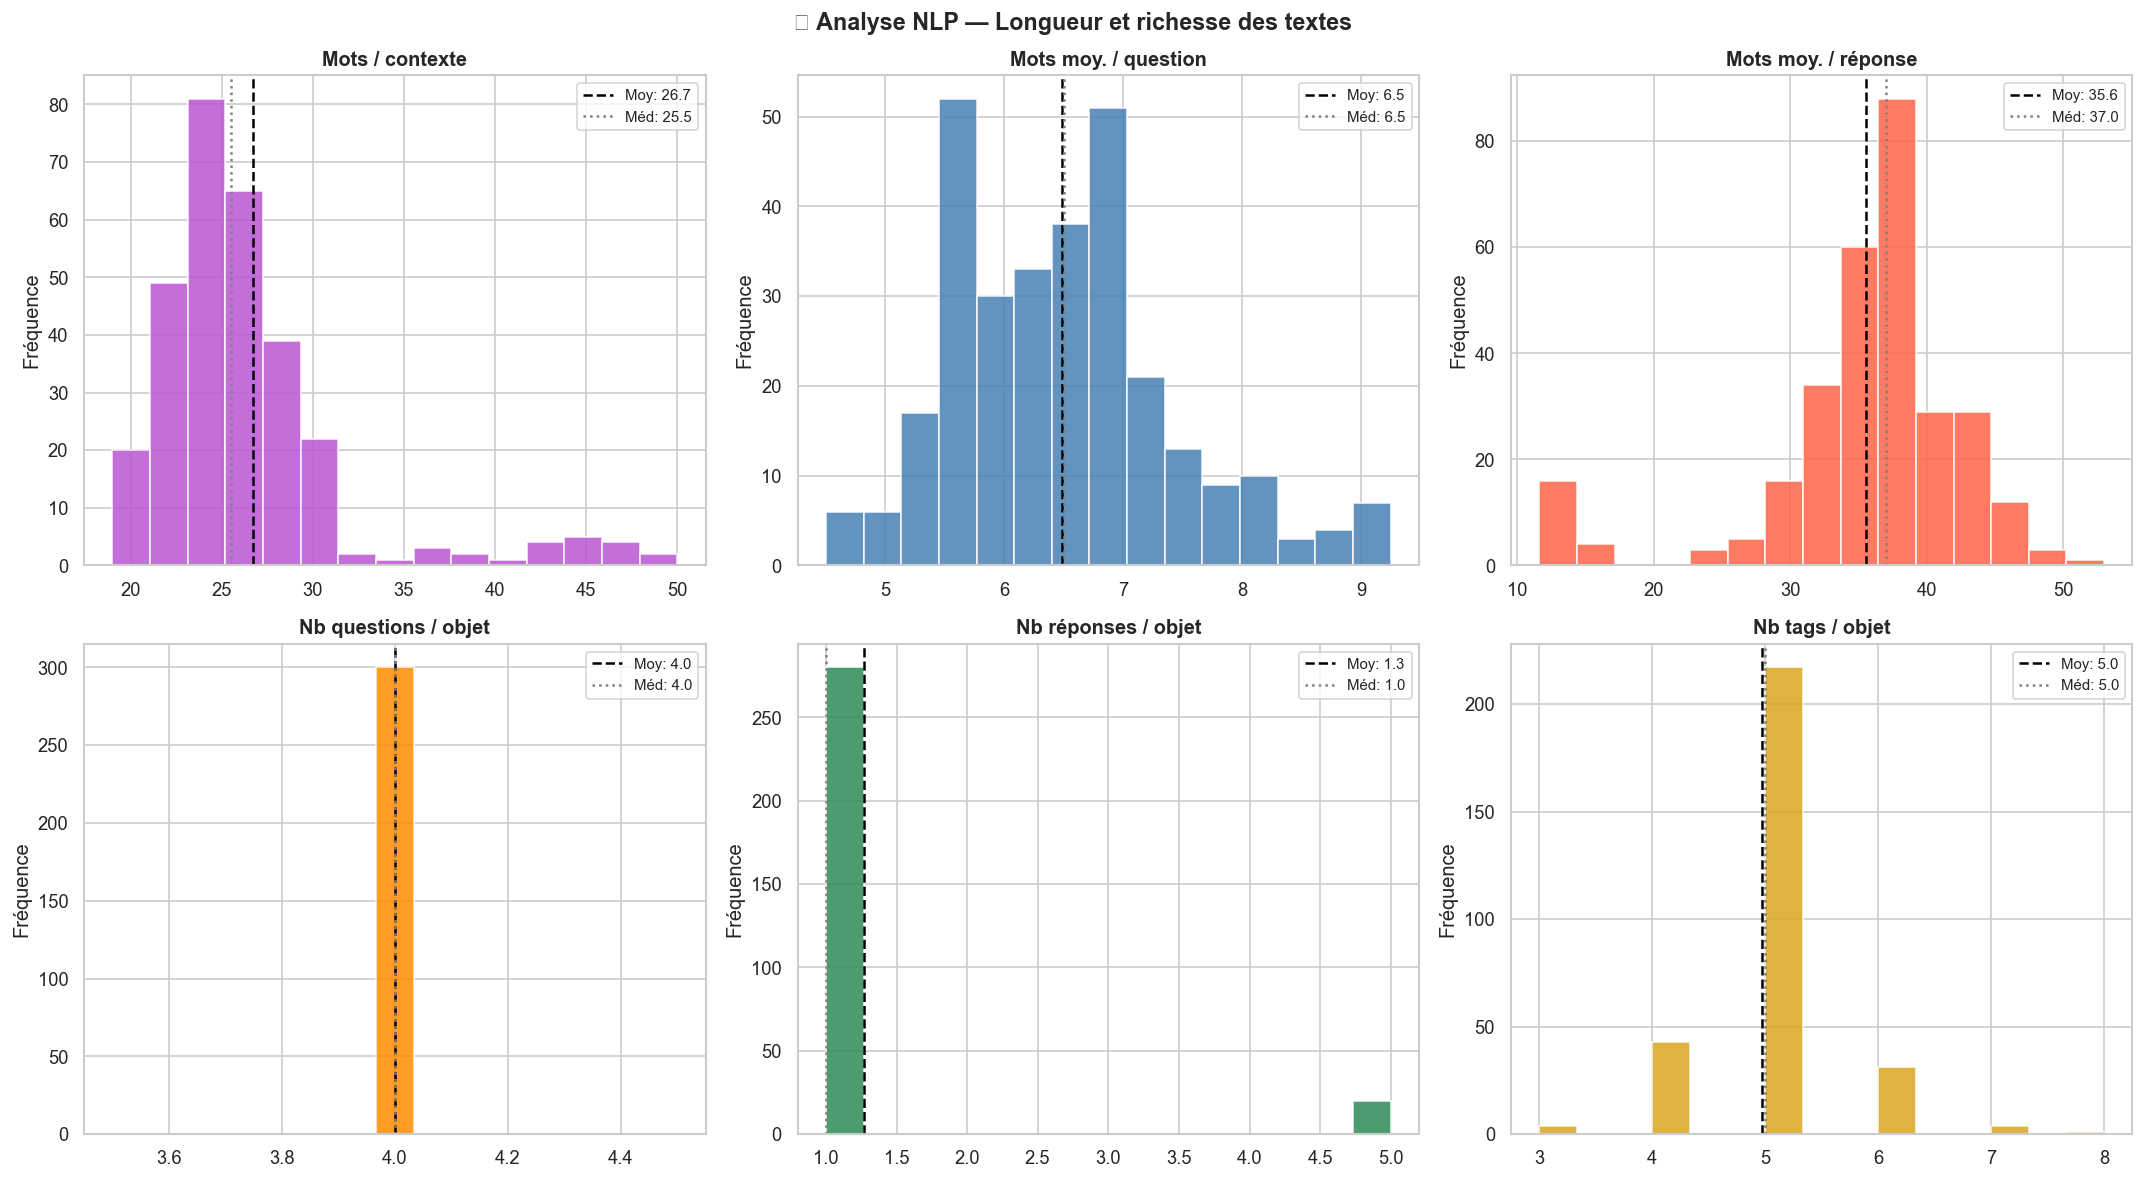

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📏 Analyse NLP — Longueur et richesse des textes', fontsize=14, fontweight='bold')

plot_configs = [
    ('ctx_words',     'Mots / contexte',          'mediumorchid'),
    ('avg_q_words',   'Mots moy. / question',     'steelblue'),
    ('avg_ans_words', 'Mots moy. / réponse',      'tomato'),
    ('nb_questions',  'Nb questions / objet',     'darkorange'),
    ('nb_answers',    'Nb réponses / objet',      'seagreen'),
    ('nb_tags',       'Nb tags / objet',          'goldenrod'),
]

for ax, (col, title, color) in zip(axes.flat, plot_configs):
    data = df_nlp[col].dropna()
    ax.hist(data, bins=15, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Moy: {data.mean():.1f}')
    ax.axvline(data.median(), color='gray', linestyle=':', linewidth=1.5,
               label=f'Méd: {data.median():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig('nlp_analysis.png', bbox_inches='tight')
plt.show()

## 8. Heatmap — couverture par fichier × catégorie

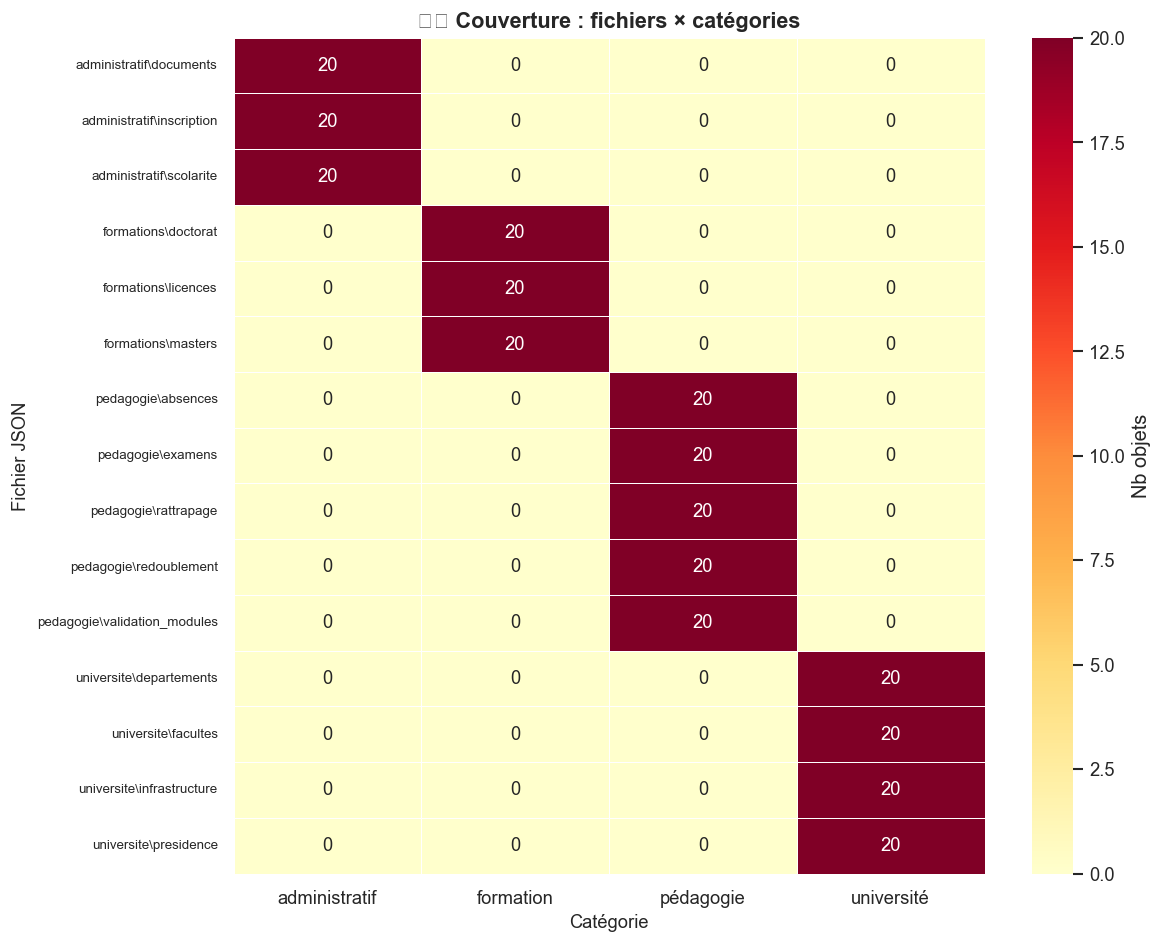

In [13]:
# Pivot : nb objets par fichier et par catégorie
df_pivot = df_nlp.groupby(['fichier', 'category']).size().reset_index(name='count')
pivot_table = df_pivot.pivot(index='fichier', columns='category', values='count').fillna(0)
pivot_table.index = [i.replace('.json','') for i in pivot_table.index]

fig, ax = plt.subplots(figsize=(10, max(8, len(pivot_table)*0.4)))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'label': 'Nb objets'})
ax.set_title('🗺️ Couverture : fichiers × catégories', fontsize=13, fontweight='bold')
ax.set_xlabel('Catégorie', fontsize=11)
ax.set_ylabel('Fichier JSON', fontsize=11)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('coverage_heatmap.png', bbox_inches='tight')
plt.show()

## 9. Analyse de la diversité lexicale (vocabulaire)

In [14]:
from collections import Counter
import re

STOPWORDS_FR = set([
    'le','la','les','de','du','des','un','une','et','en','à','au','aux',
    'est','sont','se','si','ou','que','qui','quoi','ce','il','elle','on',
    'je','tu','nous','vous','ils','elles','pour','dans','par','sur','avec',
    'pas','ne','plus','très','bien','après','avant','lors','dont','mais'
])

def tokenize(text: str) -> list:
    tokens = re.findall(r'\b[a-záàâäéèêëîïôöùûüç]{3,}\b', text.lower())
    return [t for t in tokens if t not in STOPWORDS_FR]

# Vocabulaire global des questions
q_vocab = Counter()
c_vocab = Counter()
for obj in all_objects:
    for q in obj.get('questions', []):
        q_vocab.update(tokenize(q))
    c_vocab.update(tokenize(obj.get('context', '')))

print(f'📚 Vocabulaire (questions) : {len(q_vocab)} mots uniques')
print(f'📚 Vocabulaire (contextes) : {len(c_vocab)} mots uniques')

# TTR — Type-Token Ratio (richesse lexicale)
q_tokens_total = sum(q_vocab.values())
c_tokens_total = sum(c_vocab.values())
ttr_q = len(q_vocab) / q_tokens_total
ttr_c = len(c_vocab) / c_tokens_total
print(f'\n📊 TTR Questions : {ttr_q:.4f}  ({ttr_q*100:.1f}%)')
print(f'📊 TTR Contextes : {ttr_c:.4f}  ({ttr_c*100:.1f}%)')
print('  → Plus TTR est proche de 1, plus le vocabulaire est varié')

# Top mots
print(f'\n🔝 Top 15 mots dans les questions :')
for w, c in q_vocab.most_common(15):
    print(f'   {w:20s} : {c}')

📚 Vocabulaire (questions) : 970 mots uniques
📚 Vocabulaire (contextes) : 1512 mots uniques

📊 TTR Questions : 0.2012  (20.1%)
📊 TTR Contextes : 0.3286  (32.9%)
  → Plus TTR est proche de 1, plus le vocabulaire est varié

🔝 Top 15 mots dans les questions :
   fssm                 : 1055
   comment              : 114
   master               : 102
   uca                  : 81
   rattrapage           : 80
   marrakech            : 79
   licence              : 73
   redoublement         : 45
   étudiant             : 44
   inscription          : 43
   département          : 40
   doctorat             : 36
   peut                 : 35
   examen               : 35
   modules              : 35


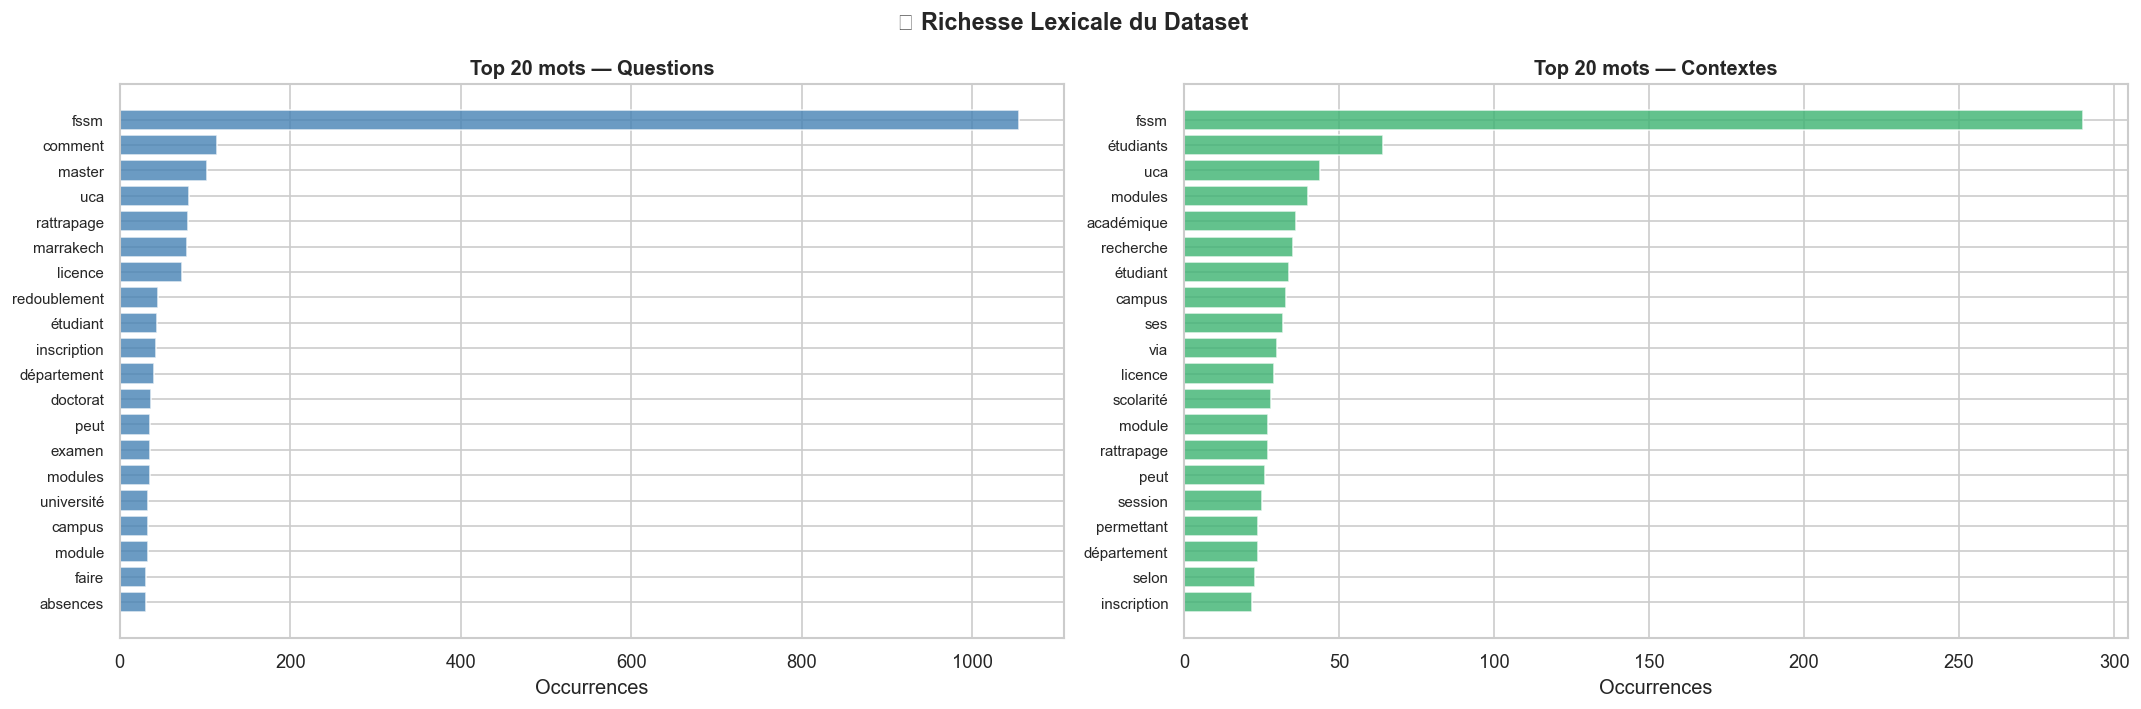

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('📚 Richesse Lexicale du Dataset', fontsize=14, fontweight='bold')

for ax, (vocab, label, color) in zip(axes, [
    (q_vocab, 'Questions', 'steelblue'),
    (c_vocab, 'Contextes', 'mediumseagreen')
]):
    top = vocab.most_common(20)
    words, counts = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, alpha=0.8)
    ax.set_title(f'Top 20 mots — {label}', fontweight='bold')
    ax.set_xlabel('Occurrences')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('vocabulary_analysis.png', bbox_inches='tight')
plt.show()

## 10. Rapport de qualité final

In [16]:
# Score de qualité par objet
def quality_score(obj: dict) -> float:
    score = 0
    # Champs présents (40 pts)
    for field in REQUIRED_FIELDS:
        if field in obj and obj[field]:
            score += 40 / len(REQUIRED_FIELDS)
    # Questions variées ≥ 3 (20 pts)
    n_q = len(obj.get('questions', []))
    score += min(20, n_q * 5)
    # Contexte riche ≥ 100 chars (20 pts)
    ctx_len = len(obj.get('context', ''))
    score += min(20, ctx_len / 10)
    # Tags ≥ 3 (10 pts)
    n_tags = len(obj.get('tags', []))
    score += min(10, n_tags * 3)
    # Format ID correct (10 pts)
    if re.match(r'^[a-z]{2,8}_[a-z]{2,8}_\d{3}$', str(obj.get('id', ''))):
        score += 10
    return min(round(score, 1), 100)

scores = [quality_score(o) for o in all_objects]
df_nlp['quality_score'] = scores

def grade(s):
    if s >= 90: return '🟢 Excellent'
    if s >= 75: return '🔵 Bon'
    if s >= 60: return '🟡 Moyen'
    return '🔴 Insuffisant'

df_nlp['grade'] = df_nlp['quality_score'].apply(grade)
grade_dist = df_nlp['grade'].value_counts()

print('\n' + '='*55)
print('        📋 RAPPORT FINAL DE QUALITÉ DU DATASET')
print('='*55)
print(f'  Total objets           : {len(all_objects)}')
print(f'  Fichiers chargés       : {len(all_data)}')
print(f'  Score moyen            : {np.mean(scores):.1f} / 100')
print(f'  Score médian           : {np.median(scores):.1f} / 100')
print(f'  Score min / max        : {min(scores):.1f} / {max(scores):.1f}')
print(f'  Taux validité structure: {valid_count/len(all_objects)*100:.1f}%')
print(f'  IDs dupliqués          : {len(dup_ids)}')
print(f'  Contextes dupliqués    : {len(dup_ctx)}')
print(f'  Questions dupliquées   : {len(dup_q)}')
print(f'  Vocabulaire unique (Q) : {len(q_vocab)} mots')
print(f'  TTR questions          : {ttr_q:.3f}')
print('\n  Distribution des grades :')
for g, cnt in grade_dist.items():
    print(f'    {g:20s} : {cnt} objets ({cnt/len(all_objects)*100:.1f}%)')
print('='*55)
print('  ✅ Dataset prêt pour le pipeline RAG' if np.mean(scores) >= 75 else '  ⚠️  Amélioration recommandée')
print('='*55)


        📋 RAPPORT FINAL DE QUALITÉ DU DATASET
  Total objets           : 300
  Fichiers chargés       : 15
  Score moyen            : 96.5 / 100
  Score médian           : 96.9 / 100
  Score min / max        : 90.0 / 100.0
  Taux validité structure: 93.3%
  IDs dupliqués          : 0
  Contextes dupliqués    : 0
  Questions dupliquées   : 3
  Vocabulaire unique (Q) : 970 mots
  TTR questions          : 0.201

  Distribution des grades :
    🟢 Excellent          : 300 objets (100.0%)
  ✅ Dataset prêt pour le pipeline RAG


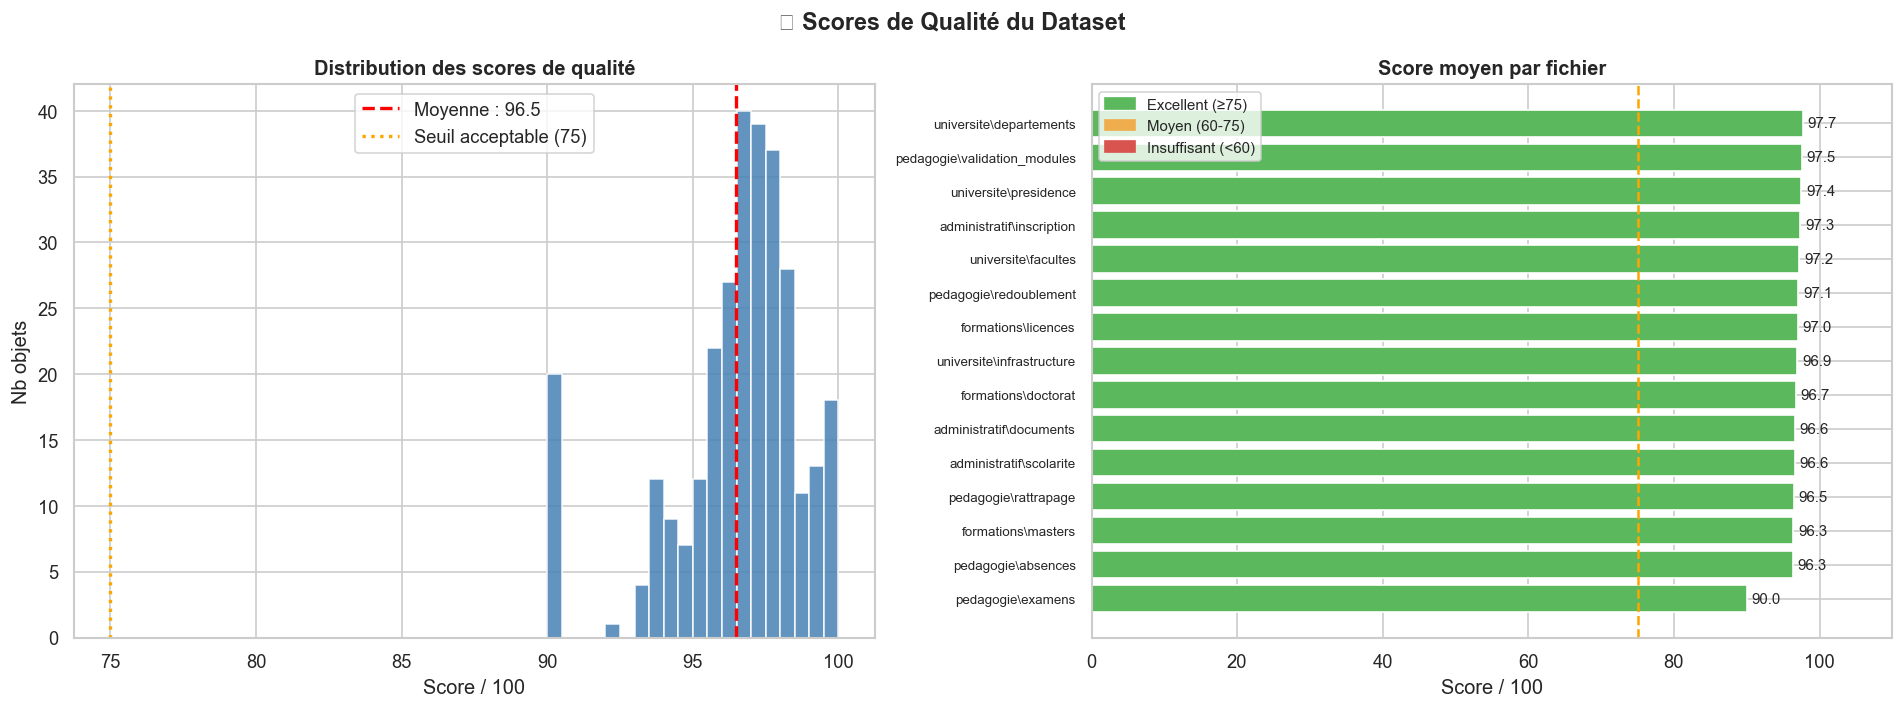


✅ Analyse terminée — tous les graphiques ont été sauvegardés.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🎯 Scores de Qualité du Dataset', fontsize=14, fontweight='bold')

# Histogramme des scores
ax = axes[0]
ax.hist(scores, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(scores), color='red', linestyle='--', linewidth=2,
           label=f'Moyenne : {np.mean(scores):.1f}')
ax.axvline(75, color='orange', linestyle=':', linewidth=2, label='Seuil acceptable (75)')
ax.set_title('Distribution des scores de qualité', fontweight='bold')
ax.set_xlabel('Score / 100')
ax.set_ylabel('Nb objets')
ax.legend()

# Score moyen par fichier
ax = axes[1]
file_scores = df_nlp.groupby('fichier')['quality_score'].mean().sort_values()
file_labels = [f.replace('.json','') for f in file_scores.index]
colors = ['#d9534f' if s < 60 else '#f0ad4e' if s < 75 else '#5cb85c' for s in file_scores]
bars = ax.barh(file_labels, file_scores, color=colors)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.axvline(75, color='orange', linestyle='--', linewidth=1.5, label='Seuil 75')
ax.set_title('Score moyen par fichier', fontweight='bold')
ax.set_xlabel('Score / 100')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(0, 110)
legend_handles = [
    mpatches.Patch(color='#5cb85c', label='Excellent (≥75)'),
    mpatches.Patch(color='#f0ad4e', label='Moyen (60-75)'),
    mpatches.Patch(color='#d9534f', label='Insuffisant (<60)'),
]
ax.legend(handles=legend_handles, fontsize=9)

plt.tight_layout()
plt.savefig('quality_scores.png', bbox_inches='tight')
plt.show()
print('\n✅ Analyse terminée — tous les graphiques ont été sauvegardés.')